# Определение стоимости автомобилей

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В вашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. Вам нужно построить модель для определения стоимости. 

Заказчику важны:

- качество предсказания;
- скорость предсказания;
- время обучения.

## Описание данных

    ##autos.csv
    
### Признаки

* DateCrawled — дата скачивания анкеты из базы
* VehicleType — тип автомобильного кузова
* RegistrationYear — год регистрации автомобиля
* Gearbox — тип коробки передач
* Power — мощность (л. с.)
* Model — модель автомобиля
* Kilometer — пробег (км)
* RegistrationMonth — месяц регистрации автомобиля
* FuelType — тип топлива
* Brand — марка автомобиля
* Repaired — была машина в ремонте или нет
* DateCreated — дата создания анкеты
* NumberOfPictures — количество фотографий автомобиля
* PostalCode — почтовый индекс владельца анкеты (пользователя)
* LastSeen — дата последней активности пользователя

### Целевой признак
* Price — цена (евро)

## Подготовка данных

In [1]:
#!pip install Levenshtein
#!pip install phik
#!pip install category-encoders

In [2]:
import pandas as pd
from Levenshtein import ratio
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import phik
import time


from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders import TargetEncoder, BinaryEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from catboost import CatBoostRegressor
import lightgbm as lgb

<div class="alert alert-block alert-success">
<b>Успех:</b> Импорты  на месте
</div>

In [59]:
df = pd.read_csv('/datasets/autos.csv')
df.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


Данные отобразилсь корректно, нужно будет привести названия колонок к змеиному формату. 

Посмотрим верно ли считались типы данных

In [60]:
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Kilometer          354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  Repaired           283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

None

,Price,RegistrationYear,Power,Kilometer,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


Необходимо будет поменять формат у колонок с датами и временем или 

354 369 строк

In [61]:
df.isna().sum()

DateCrawled              0
Price                    0
VehicleType          37490
RegistrationYear         0
Gearbox              19833
Power                    0
Model                19705
Kilometer                0
RegistrationMonth        0
FuelType             32895
Brand                    0
Repaired             71154
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64

Также имеются пропуски в данных, которые мы посмотрим более детально, чтобы верно их заполнить или оставить как есть. 

In [62]:
df.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


* DateCrawled — дата скачивания анкеты из базы
* DateCreated — дата создания анкеты
* NumberOfPictures — количество фотографий автомобиля
* PostalCode — почтовый индекс владельца анкеты (пользователя)
* LastSeen — дата последней активности пользователя

Вышеуказанные колонки нам не помогут в прогнозе цен на автомибль тк описывают лишь поведение пользователя при оформлении объявления. Можем их убрать из датафрейма без ухудшения качества прогноза. 

In [63]:
#Удалим столбцы которые нам не понадобятся
df=df.drop(['DateCrawled','DateCreated','PostalCode','LastSeen','NumberOfPictures'], axis=1)


<div class="alert alert-block alert-success">
<b>Успех:</b> Удалить неинформативные признаки - верное решение
</div>

In [64]:
df.head(1)

,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired
0,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN


In [65]:
#Приведем наименования к змеиному формату и отсортируем порядок колонок в более привычный вид
df.columns = df.columns.str.lower()
column_names = ['brand', 
                'model', 
                'gearbox',
                'fueltype', 
                'vehicletype', 
                'power',
                'registrationyear', 
                'registrationmonth', 
                'kilometer',
                'repaired', 
                'price']
df = df.reindex(columns=column_names)

In [66]:
df.head()

,brand,model,gearbox,fueltype,vehicletype,power,registrationyear,registrationmonth,kilometer,repaired,price
0,volkswagen,golf,manual,petrol,NaN,0,1993,0,150000,NaN,480
1,audi,NaN,manual,gasoline,coupe,190,2011,5,125000,yes,18300
2,jeep,grand,auto,gasoline,suv,163,2004,8,125000,NaN,9800
3,volkswagen,golf,manual,petrol,small,75,2001,6,150000,no,1500
4,skoda,fabia,manual,gasoline,small,69,2008,7,90000,no,3600


In [67]:
#Сделаем более удобный вид в колонке для лучшей восприимчивости моделью
df['repaired'] = df['repaired'].map({'yes':1, 'no':0})

In [68]:
#Посмотрим на количество пустых значений в оставшемся датасете
df.isna().sum()

brand                    0
model                19705
gearbox              19833
fueltype             32895
vehicletype          37490
power                    0
registrationyear         0
registrationmonth        0
kilometer                0
repaired             71154
price                    0
dtype: int64

In [69]:
df.shape

(354369, 11)

In [70]:
#пустоты заменим "неизвестно" тк в действительности нет смысла угадывать что тм могло быть
df = df.fillna('unknown')

In [71]:
df.head()

,brand,model,gearbox,fueltype,vehicletype,power,registrationyear,registrationmonth,kilometer,repaired,price
0,volkswagen,golf,manual,petrol,unknown,0,1993,0,150000,unknown,480
1,audi,unknown,manual,gasoline,coupe,190,2011,5,125000,1.0,18300
2,jeep,grand,auto,gasoline,suv,163,2004,8,125000,unknown,9800
3,volkswagen,golf,manual,petrol,small,75,2001,6,150000,0.0,1500
4,skoda,fabia,manual,gasoline,small,69,2008,7,90000,0.0,3600


In [72]:
#проверим сколько уникальных значений в каждой категориальной колонке
df.nunique()

brand                  40
model                 251
gearbox                 3
fueltype                8
vehicletype             9
power                 712
registrationyear      151
registrationmonth      13
kilometer              13
repaired                3
price                3731
dtype: int64

Странные данные registrationyear и registrationmonth т.к.:

RegistrationYear — год регистрации автомобиля (данные за 149 лет?)

RegistrationMonth — месяц регистрации автомобиля (их почему-то у нас 13, хотя всего месяцев 12)

In [73]:
display(df['registrationyear'].min())
display(df['registrationyear'].max()) #будем убирать аномалии позже

1000

9999

In [74]:
#проверим наличие неявных дубликатов вручную
df['vehicletype'].value_counts()

sedan          91457
small          79831
wagon          65166
unknown        37490
bus            28775
convertible    20203
coupe          16163
suv            11996
other           3288
Name: vehicletype, dtype: int64

Колонки fueltype, vehicletype содержат две категории, которые можно объединить - это other и unknown  

In [75]:
df['fueltype'].value_counts()

petrol      216352
gasoline     98720
unknown      32895
lpg           5310
cng            565
hybrid         233
other          204
electric        90
Name: fueltype, dtype: int64

In [76]:
df["fueltype"] = df["fueltype"].replace({"other": "unknown"})
df["vehicletype"] = df["vehicletype"].replace({"other": "unknown"})

Уделим внимание колонке model ведь там много категорий и наверняка могут быть опечатки, которые мы будем исправлять. Применим чуть другой способ

In [77]:
# Удаление дубликатов и получение уникальных станций
unique_models = df['model'].dropna().unique()

# Установка порога схожести (например, 0.8 = 80%)
threshold = 0.9
similar_pairs = []

# Поиск похожих станций
for i in range(len(unique_models)):
    for j in range(i + 1, len(unique_models)):
        similarity = ratio(unique_models[i], unique_models[j])
        if similarity >= threshold:
            similar_pairs.append((unique_models[i], unique_models[j], round(similarity, 2)))

# Вывод похожих пар станций
for pair in similar_pairs:
    print(f"Пара: {pair[0]} и {pair[1]} - Похожесть: {pair[2]}")

Пара: xc_reihe и x_reihe - Похожесть: 0.93
Пара: xc_reihe и c_reihe - Похожесть: 0.93
Пара: rx_reihe и x_reihe - Похожесть: 0.93
Пара: x_reihe и mx_reihe - Похожесть: 0.93
Пара: x_reihe и cx_reihe - Похожесть: 0.93
Пара: mx_reihe и m_reihe - Похожесть: 0.93
Пара: cr_reihe и c_reihe - Похожесть: 0.93
Пара: c_reihe и cx_reihe - Похожесть: 0.93
Пара: range_rover и rangerover - Похожесть: 0.95


Можем объединить range_rover и rangerover

In [78]:
df["model"] = df["model"].replace({"rangerover": "range_rover"})

In [79]:
#Посмотрим на количество дубликатов в оставшемся датасете
df.duplicated().sum()

27560

In [80]:
df = df.drop_duplicates() #убираем дубли

In [81]:
df.shape

(326809, 11)

In [82]:
column_file = ['power', 'kilometer', 'price']

In [83]:
#создание функции для построения гистограммы и диаграммы размаха для столбцов с количественными признаками
def hist_box(data, column):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.xlabel(f'Значения столбца "{column}"')
    plt.ylabel('Частота')
    plt.title(f'Гистограмма для "{column}"')
    sns.histplot(data[column], color='Green')
    plt.subplot(1, 2, 2)
    plt.xlabel(f'Значения столбца {column}')
    plt.title(f'Диаграмма размаха для {column}')
    sns.boxplot(x=data[column], color='Orange')

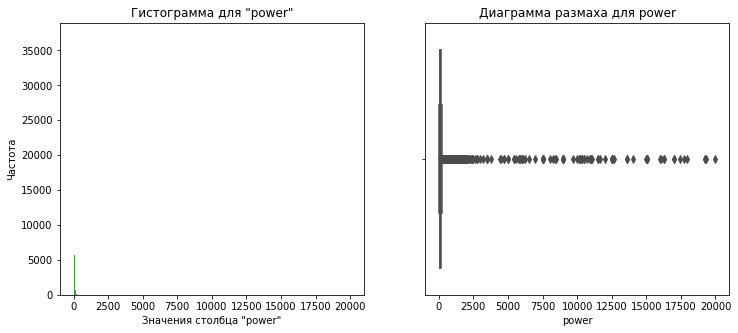

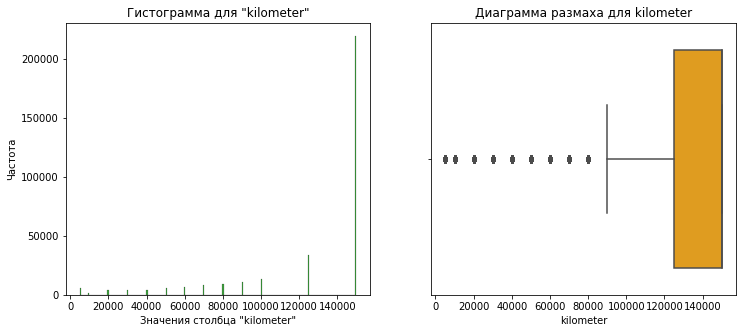

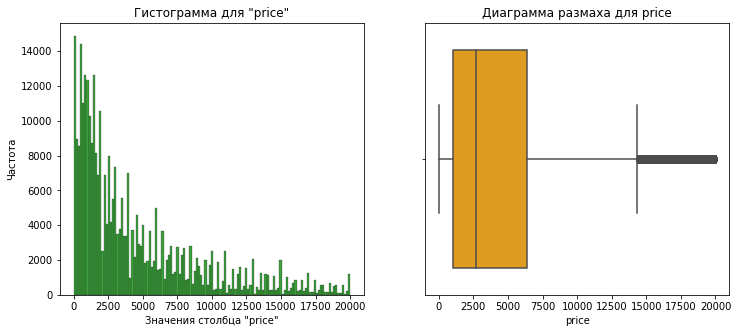

In [84]:
#построение распределений
for name in column_file:
    hist_box(df, name)

Исключаем из данных редкие значения и аномалии:
* power - мощность в л.с. в некоторых случаях 400 и более, вероятнее всего это ошибка, также исключим мощность менее 20 л.с., раз уж наблюдаем много объявлений с мощьностью около 0 л.с.


Остальные значения редкие, но не являются аномальными. Пока что их оставим

In [85]:
df = df.loc[df['power'] <= 400, :]
df = df.loc[df['power'] > 20, :]

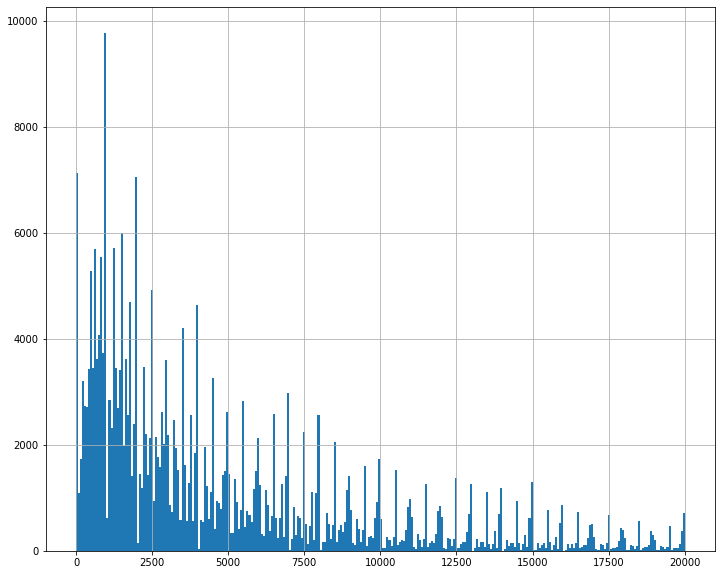

In [86]:
df['price'].hist(bins=300, figsize=(12, 10));

In [87]:
#исключим "супер дешевые автомобили"
df = df.loc[df['price'] > 100, :]

In [88]:
df.sort_values(by="price").head(20)

,brand,model,gearbox,fueltype,vehicletype,power,registrationyear,registrationmonth,kilometer,repaired,price
332022,hyundai,i_reihe,manual,petrol,small,86,2015,11,5000,0.0,101
221816,opel,corsa,manual,petrol,small,60,1999,3,150000,1.0,101
90696,hyundai,i_reihe,manual,petrol,small,85,2015,11,5000,0.0,101
114154,renault,other,manual,petrol,coupe,140,1997,0,150000,1.0,105
25683,volkswagen,golf,manual,unknown,wagon,60,1994,0,5000,unknown,105
345547,renault,twingo,auto,petrol,small,53,1997,2,125000,unknown,108
95708,volkswagen,polo,manual,petrol,small,45,1991,0,150000,unknown,110
47394,ford,mondeo,manual,unknown,sedan,90,1996,1,150000,unknown,110
206498,renault,espace,manual,petrol,bus,140,1999,4,150000,0.0,110
49346,volkswagen,polo,manual,petrol,small,55,1991,0,150000,unknown,110


Исключим авто, стоимость которых ниже 100 евро, как будто это ошибочно указанные цены или кликбейтные объявления

In [89]:
categ_col = ['model', 
             'gearbox', 
             'fueltype', 
             'vehicletype', 
             'registrationyear',
             'registrationmonth', 
             'repaired']

In [90]:
def count_box(data, column):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.xlabel(f'Значения столбца "{column}"')
    plt.ylabel('Частота')
    plt.title(f'График распределения для "{column}"')
    sns.countplot(x=data[column], data=data);

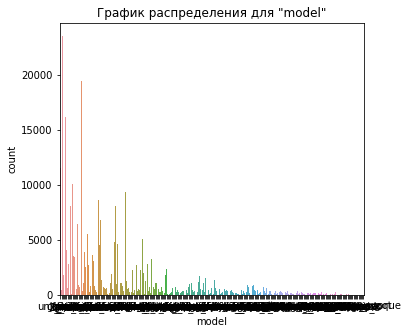

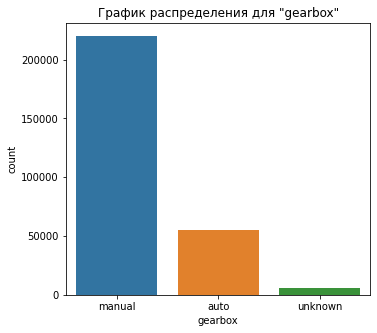

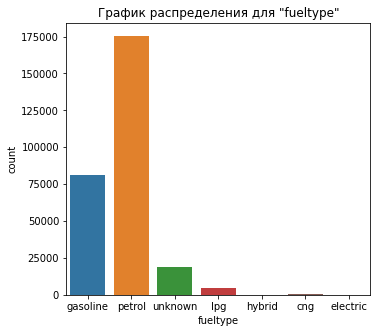

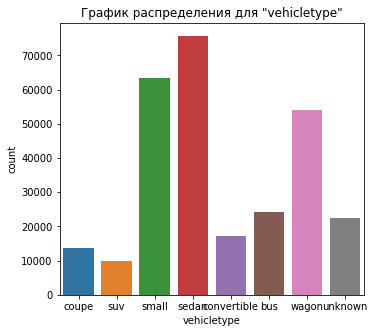

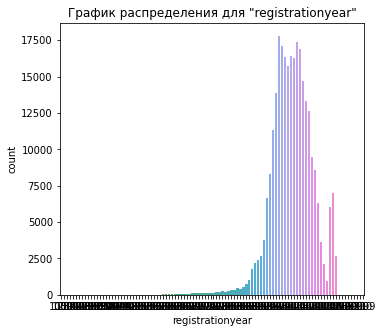

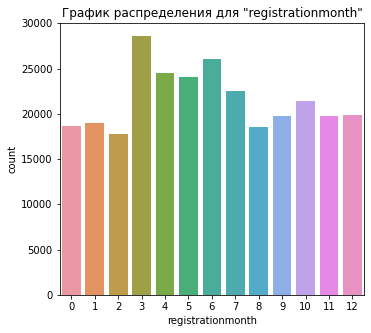

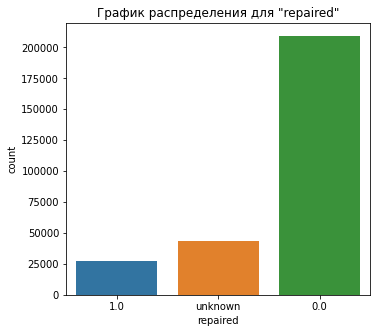

In [91]:
for name in categ_col:
    count_box(df, name)

In [92]:
df.describe()

,power,registrationyear,registrationmonth,kilometer,price
count,280710.000000,280710.000000,280710.000000,280710.000000,280710.000000
mean,119.973457,2003.456617,5.951120,128462.790781,4810.514000
std,52.351863,27.908350,3.600463,36647.328539,4579.569478
min,21.000000,1000.000000,0.000000,5000.000000,101.000000
25%,75.000000,1999.000000,3.000000,125000.000000,1333.000000
50%,110.000000,2003.000000,6.000000,150000.000000,3100.000000
75%,150.000000,2008.000000,9.000000,150000.000000,6900.000000
max,400.000000,9999.000000,12.000000,150000.000000,20000.000000


In [93]:
df = df.loc[df['registrationyear'] >= 1982, :]
df = df.loc[df['registrationyear'] <= 2025, :]

In [94]:
df = df.reset_index(drop = True)

# Вывод:

* Провели очистку данных от аномальных значений 
    - Были выявлены нереально мощные авто, которых не существует в природе;
    - также авто с минимальной мощностью тоже не выглядели реалистичными. и это данные были восприняты как аномалии и исключены;
    - были исключены странные периоды по годам, таки годы когда авто еще не были изобретены и годы, которые еще не наступилии;
    - исключены объявления со стоимостью автомобиля 100 евро и более дешевые, предположительно это или кликбейтные объявления или ошибочно указанные цены
* Заменили пустые значения
* Убрали неявные и явные дубликаты
* Перевели категориальные данные в номинальные с помощью LabelEncoder
* Провели стандартизацию
* отобразили коэффициенты зависимостей параметров друг от друга

## Обучение моделей

In [95]:
print(df.isna().sum())  # Проверка на NaN

brand                0
model                0
gearbox              0
fueltype             0
vehicletype          0
power                0
registrationyear     0
registrationmonth    0
kilometer            0
repaired             0
price                0
dtype: int64


In [96]:
# разделим данные на выборки: признаки, целевой признак
features = df.drop('price', axis=1)
target = df['price']

# разделим на обучающую и тестовую выборки в пропорции 4 к 1
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.20, random_state=42)

# разделим на обучающую выборку на обучающую и тестовую в пропорции 3 к 1
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

In [97]:
# данные о размере выборок
print('размеры выборок на train: ', X_train.shape, y_train.shape) 
print('размеры выборок на valid: ', X_valid.shape, y_valid.shape) 
print('размеры выборок на test: ', X_test.shape, y_test.shape) 

размеры выборок на train:  (166935, 10) (166935,)
размеры выборок на valid:  (55645, 10) (55645,)
размеры выборок на test:  (55645, 10) (55645,)


In [98]:
def encode_categorical_features(X_train, X_valid, X_test, y_train):
    categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    
    #TargetEncoder
    target_encoder = TargetEncoder(cols=categorical_cols)
    X_train_enc = X_train.copy()
    X_valid_enc = X_valid.copy()
    X_test_enc = X_test.copy()

    X_train_enc[categorical_cols] = target_encoder.fit_transform(X_train[categorical_cols], y_train)
    X_valid_enc[categorical_cols] = target_encoder.transform(X_valid[categorical_cols])
    X_test_enc[categorical_cols] = target_encoder.transform(X_test[categorical_cols])
    
    #BinaryEncoder
    binary_encoder = BinaryEncoder(cols=categorical_cols, drop_invariant=True)
    X_train_enc = binary_encoder.fit_transform(X_train_enc)
    X_valid_enc = binary_encoder.transform(X_valid_enc)
    X_test_enc = binary_encoder.transform(X_test_enc)
    
    return X_train_enc, X_valid_enc, X_test_enc

# Применяем кодирование
X_train, X_valid, X_test = encode_categorical_features(X_train, X_valid, X_test, y_train)

# Проверяем, есть ли числовые признаки
print(X_train.columns)

# Масштабирование числовых признаков
numeric = ['registrationyear', 'power', 'kilometer']
if all(col in X_train.columns for col in numeric):
    scaler = StandardScaler()
    scaler.fit(X_train[numeric])
else:
    print("Ошибка: Отсутствуют ожидаемые числовые признаки!")

Index(['brand_0', 'brand_1', 'brand_2', 'brand_3', 'brand_4', 'brand_5',
       'model_0', 'model_1', 'model_2', 'model_3', 'model_4', 'model_5',
       'model_6', 'model_7', 'gearbox_0', 'gearbox_1', 'fueltype_0',
       'fueltype_1', 'fueltype_2', 'vehicletype_0', 'vehicletype_1',
       'vehicletype_2', 'vehicletype_3', 'power', 'registrationyear',
       'registrationmonth', 'kilometer', 'repaired_0', 'repaired_1'],
      dtype='object')


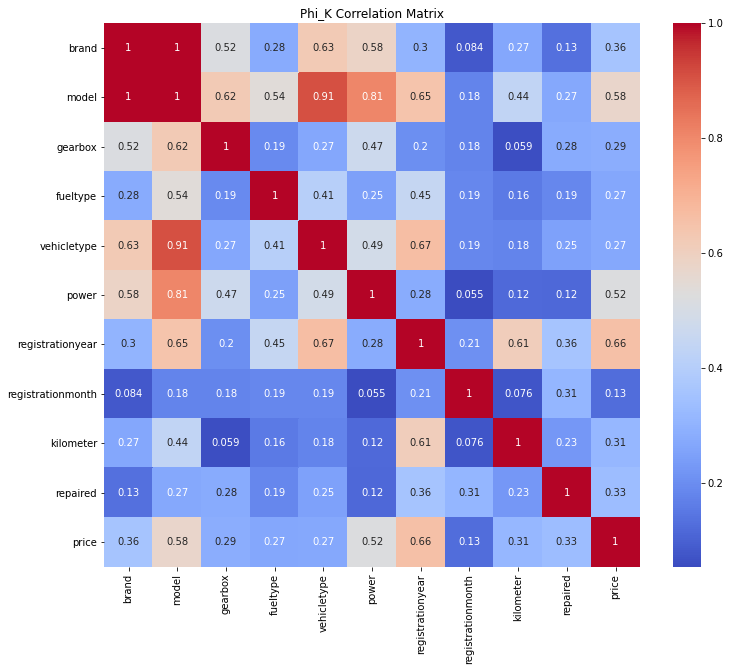

In [101]:
#вычисление матрицы корреляции
corr_matrix = df.phik_matrix(interval_cols=['price', 'power', 'kilometer'])


#визуализация матрицы корреляции 
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Phi_K Correlation Matrix');

* Нужно учитывать высокую корреляцию между model и vehicletype, чтобы избежать мультиколлинеарности;
* Признаки с низкой корреляцией (например, registratiomonth) могут быть менее значимыми для прогнозирования цены.

# LinearRegression

In [102]:
model_lr = LinearRegression()

start_time = time.time()

model_lr.fit(X_train, y_train)
end_time = time.time()
training_time_lr = end_time - start_time

# время обучения модели LinearRegression
print(f'Время обучения LinearRegression: {training_time_lr:.2f} секунд')

# время предсказания модели LinearRegression на валидационной выборке:
start_time = time.time()
predict_lr = model_lr.predict(X_valid)
end_time = time.time()
prediction_time_lr = end_time - start_time
print(f'Время предсказания LinearRegression: {prediction_time_lr:.2f} секунд')

# оценка качества модели LR на валидационной выборке:
rmse_lr = mean_squared_error(y_valid, predict_lr, squared=False)
print(f'RMSE LR на валидационной выборке: {rmse_lr:.2f}')

Время обучения LinearRegression: 0.45 секунд
Время предсказания LinearRegression: 0.01 секунд
RMSE LR на валидационной выборке: 2633.72


# CatBoostRegressor

In [103]:
start_time = time.time()

model_catboost = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=10, loss_function='RMSE', 
                                   random_state=42)
model_catboost.fit(X_train, y_train, verbose=100)

end_time = time.time()
training_time_cbr = end_time - start_time

# время обучения модели CatBoostRegressor
print(f'время обучения CatBoostRegressor: {training_time_cbr:.2f} секунд')

0:	learn: 4244.8731328	total: 73ms	remaining: 1m 12s
100:	learn: 1546.3413776	total: 5.98s	remaining: 53.3s
200:	learn: 1447.6131809	total: 11.9s	remaining: 47.2s
300:	learn: 1394.0728418	total: 17.7s	remaining: 41.1s
400:	learn: 1352.1054222	total: 23.6s	remaining: 35.3s
500:	learn: 1318.1928594	total: 29.6s	remaining: 29.5s
600:	learn: 1289.0910185	total: 35.4s	remaining: 23.5s
700:	learn: 1266.6830567	total: 41.2s	remaining: 17.6s
800:	learn: 1243.5233322	total: 47.1s	remaining: 11.7s
900:	learn: 1225.5541986	total: 53.1s	remaining: 5.84s
999:	learn: 1208.0580232	total: 59s	remaining: 0us
время обучения CatBoostRegressor: 60.31 секунд


In [104]:
# Время предсказания модели CatBoostRegressor на валидационной выборке
start_time = time.time()
predict_catboost = model_catboost.predict(X_valid)
end_time = time.time()
prediction_time_cbr = end_time - start_time
print(f'время предсказания CatBoostRegressor: {prediction_time_cbr:.2f} секунд')

время предсказания CatBoostRegressor: 0.25 секунд


In [105]:
# Оценка качества модели CatBoostRegressor на валидационной выборке
rmse_catboost = mean_squared_error(y_valid, predict_catboost, squared=False)
print(f'RMSE CatBoostRegressor на валидационной выборке: {rmse_catboost:.2f}')

RMSE CatBoostRegressor на валидационной выборке: 1512.51


# LightGBM

In [106]:
start_time = time.time()

model_gbm = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.1, max_depth=10, random_state=42)

model_gbm.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], early_stopping_rounds=50, verbose=100)

end_time = time.time()
training_time_gbm = end_time - start_time

# время обучения модели LightGBM
print(f'время обучения LightGBM: {training_time_gbm:.2f} секунд')

/opt/conda/lib/python3.9/site-packages/lightgbm/sklearn.py:726: UserWarning: 'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. Pass 'early_stopping()' callback via 'callbacks' argument instead.
  _log_warning("'early_stopping_rounds' argument is deprecated and will be removed in a future release of LightGBM. "
/opt/conda/lib/python3.9/site-packages/lightgbm/sklearn.py:736: UserWarning: 'verbose' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
  _log_warning("'verbose' argument is deprecated and will be removed in a future release of LightGBM. "


[100]	valid_0's l2: 2.79471e+06
[200]	valid_0's l2: 2.60966e+06
[300]	valid_0's l2: 2.52857e+06
[400]	valid_0's l2: 2.48457e+06
[500]	valid_0's l2: 2.4485e+06
[600]	valid_0's l2: 2.42488e+06
[700]	valid_0's l2: 2.40546e+06
[800]	valid_0's l2: 2.39284e+06
[900]	valid_0's l2: 2.38537e+06
[1000]	valid_0's l2: 2.3762e+06
время обучения LightGBM: 37.50 секунд


In [107]:
# Время предсказания модели LightGBM на валидационной выборке
start_time = time.time()
predict_gbm = model_gbm.predict(X_valid)
end_time = time.time()
prediction_time_gbm = end_time - start_time
print(f'время предсказания LightGBM: {prediction_time_gbm:.2f} секунд')

время предсказания LightGBM: 5.94 секунд


In [108]:
# оценка качества модели LightGBM на валидационной выборке
rmse_gbm = mean_squared_error(y_valid, predict_gbm, squared=False)
print(f'RMSE LightGBM на валидационной выборке: {rmse_gbm:.2f}')

RMSE LightGBM на валидационной выборке: 1541.49


# Вывод: 


* Подготовили три модели без подбора гиперпараметров и сравнили время обучения разных моделей и качество прогнозов:

* LinearRegression : 2633 на тестовой выборке, время обучения : 0.45 сек  
* CatBoost : 1512 на тестовой выборке, время обучения : 60 сек
* LightGBM : 1541 на тестовой выборке, время обучения : 37 сек





На этом этапе лучшие показатели дает CatBoost


## Анализ моделей

In [110]:
# Данные о моделях
models_data = {
    'Модель': ['LinearRegression', 'CatBoostRegressor', 'LightGBM'],
    'Время обучения (сек)': [training_time_lr, training_time_cbr, training_time_gbm],
    'Время предсказания (сек)': [prediction_time_lr, prediction_time_cbr, prediction_time_gbm],
    'RMSE (валидация)': [rmse_lr, rmse_catboost, rmse_gbm]
}

# Создание DataFrame
df_models = pd.DataFrame(models_data)

# Вывод таблицы
display(df_models)

,Модель,Время обучения (сек),Время предсказания (сек),RMSE (валидация)
0,LinearRegression,0.453582,0.008810,2633.715222
1,CatBoostRegressor,60.306700,0.254527,1512.506404
2,LightGBM,37.497568,5.944308,1541.493874


Оценим лучшую модель на тестовой выборке

In [114]:
# Оценка качества модели CatBoostRegressor на тестовой выборке
predict_catboost = model_catboost.predict(X_test)
rmse_catboost_test = mean_squared_error(y_test, predict_catboost, squared=False)
print(f'RMSE CatBoostRegressor на тестовой выборке: {rmse_catboost_test:.2f}')

RMSE CatBoostRegressor на тестовой выборке: 1517.20


# Вывод: 

Модели градиентного бустинга(CatBoostRegressor и LightGBM) демонстрируют хорошие показатели точности и времени обучения и прогноза, при этом линейная регрессия сильно отстает в точности.

Лучшей моделью по всем показателям стала CatBoostRegressor, которая быстрее, чем LightGBM обучилась на данных (60 сек) и дает прогнозы весьма быстро (0.25 сек), а качество при этом сильно превосходит быструю линейную регрессии и дает нам метрику RMSE = 1512. 

На тестовой выборке лучшая модель CatBoostRegressor показала RMSE = 1517. 

<div class="alert alert-block alert-info">
<b>Совет:</b> 

Также если говорить, что можно ещё улучшить в подобных проектах, то я бы выделил такие моменты:<br>
    
1) Для понимания, а какие в итоге факторы важны при моделировании, можно выводить их важность, использую feature_importances_, ну и график заодно. Это будет смотреться очнь здорово: результативная метрика и график важности факторов)))
    
2) У нас разный возраст машин. Есть гипотеза, что для разных возрастов - своё ценообразование. Поэтому, можно попробовать ввести фактор "тип возраста" (ретро, супер-ретро, старая, новая... надо подумать..)..<br>

3) У некоторых моделей семейства бустингов, есть внутренний метод кодировки данных, который хорошо было бы попробовать
</div>

## Чек-лист проверки

Поставьте 'x' в выполненных пунктах. Далее нажмите Shift+Enter.

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Выполнена загрузка и подготовка данных
- [x]  Выполнено обучение моделей
- [x]  Есть анализ скорости работы и качества моделей